In [1]:
!pip install xarray netCDF4
! pip install matplotlib seaborn

In [ ]:
import sys
!{sys.executable} -m pip install scikit-learn

In [3]:
!{sys.executable} -m pip install -r requirements.txt

  Using cached accelerate-1.10.1-py3-none-any.whl.metadata (19 kB)
  Using cached aiofiles-25.1.0-py3-none-any.whl.metadata (6.3 kB)
  Using cached aiohappyeyeballs-2.6.1-py3-none-any.whl.metadata (5.9 kB)
  Using cached aiohttp-3.10.11-cp310-cp310-macosx_11_0_arm64.whl.metadata (7.7 kB)
  Using cached aiohttp_retry-2.8.3-py3-none-any.whl.metadata (8.9 kB)
  Using cached aioice-0.10.1-py3-none-any.whl.metadata (4.1 kB)
  Using cached aiortc-1.14.0-py3-none-any.whl.metadata (4.9 kB)
  Using cached aiosignal-1.4.0-py3-none-any.whl.metadata (3.7 kB)
  Using cached aiosqlite-0.21.0-py3-none-any.whl.metadata (4.3 kB)
  Using cached albucore-0.0.33-py3-none-any.whl.metadata (7.8 kB)
  Using cached albumentationsx-2.0.11-py3-none-any.whl.metadata (79 kB)
  Using cached annotated_types-0.7.0-py3-none-any.whl.metadata (15 kB)
  Using cached anthropic-0.49.0-py3-none-any.whl.metadata (24 kB)
  Using cached anyio-4.11.0-py3-none-any.whl.metadata (4.1 kB)
  Using cached anywidget-0.9.18-py3-none-a

In [4]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import pandas as pd
from sklearn.metrics import (
    f1_score, precision_score, recall_score, roc_auc_score,
    average_precision_score
)
import os
import imageio.v2 as imageio
from datetime import datetime, timedelta
from scipy import ndimage


In [5]:
clean_ds = xr.open_dataset("merged_clean_cn_land_pressure_fixed.nc")
print(clean_ds)

<xarray.Dataset> Size: 4GB
Dimensions:      (lon: 264, lat: 141, time: 2790)
Coordinates:
  * lon          (lon) float32 1kB -25.0 -24.75 -24.49 ... 40.5 40.75 41.0
  * lat          (lat) float32 564B 35.8 36.05 36.3 36.55 ... 70.5 70.75 71.0
  * time         (time) datetime64[ns] 22kB 1990-06-01 1990-06-02 ... 2020-08-31
Data variables:
    DC           (time, lat, lon) float32 415MB ...
    CC           (time, lat, lon) float32 415MB ...
    BC           (time, lat, lon) float32 415MB ...
    ID           (time, lat, lon) float32 415MB ...
    OD           (time, lat, lon) float32 415MB ...
    is_heatwave  (time, lat, lon) float32 415MB ...
    swvl1        (time, lat, lon) float32 415MB ...
    land_mask    (time, lat, lon) bool 104MB ...
    u            (time, lat, lon) float32 415MB ...
    v            (time, lat, lon) float32 415MB ...
    z            (time, lat, lon) float32 415MB ...


## Build X and next-day target Y - choose COEFFICIENTS AND TARGET

In [6]:
def choose_coefficients_and_target(ds, coeffs, target):
    return xr.concat([ds[coeff] for coeff in coeffs], dim="channel").assign_coords(channel=list(coeffs)), ds[target]

COEFFS = ["BC", "DC", "ID", "OD", "is_heatwave", "swvl1", "land_mask", "u", "v", "z"]  # change this list to include the coefficients you want to use as input features (e.g. if you want to predict CC, you can remove it from the input features and only keep it as target)
TARGET = "CC"  # change this to the target variable you want to predict (e.g. if you want to do regression and predict CC, change this to "CC")
TASK_TYPE = "CC_regression"  # or "binary" or "CC_regression" 

# X coefficients at time t
X, y = choose_coefficients_and_target(clean_ds, COEFFS, TARGET)

# target y at time t+1
y = y.shift(time=-1)

# drop last time step (because y(t+1) missing at end)
X = X.isel(time=slice(None, -1))
y = y.isel(time=slice(None, -1))

print("X:", X.dims, X.shape)   
print("y:", y.dims, y.shape)
print("channels:", [str(c) for c in X.channel.values])

X: ('channel', 'time', 'lat', 'lon') (10, 2789, 141, 264)
y: ('time', 'lat', 'lon') (2789, 141, 264)
channels: ['BC', 'DC', 'ID', 'OD', 'is_heatwave', 'swvl1', 'land_mask', 'u', 'v', 'z']


## Adjust to the Iberia region

In [ ]:
# # Iberia bounding box 
# lon_min, lon_max = -10, 4
# lat_min, lat_max = 36, 44

## Adjust to the Scandinavia region 

In [7]:
lon_min, lon_max = 5, 32
lat_min, lat_max = 54, 72

## Adjust to the Mediterranean basin

In [ ]:
# lon_min, lon_max = -10, 40
# lat_min, lat_max = 30, 48

In [8]:
X_ib = X.sel(lon=slice(lon_min, lon_max), lat=slice(lat_min, lat_max))
y_ib = y.sel(lon=slice(lon_min, lon_max), lat=slice(lat_min, lat_max))

print("X_ib:", X_ib.shape, X_ib.dims)
print("y_ib:", y_ib.shape, y_ib.dims)

X_ib: (10, 2789, 68, 108) ('channel', 'time', 'lat', 'lon')
y_ib: (2789, 68, 108) ('time', 'lat', 'lon')


## Use the range 1990-2018

In [10]:
X_0103 = X_ib.sel(time=slice("1995-06-01", "2018-08-31"))
y_0103 = y_ib.sel(time=slice("1995-06-01", "2018-08-31"))

print("Time range:", str(X_0103.time.values[0]), "→", str(X_0103.time.values[-1]))

Time range: 1995-06-01T00:00:00.000000000 → 2018-08-31T00:00:00.000000000


## Yearly sequences

In [11]:
def make_sequences_per_year(X, y, seq_len=14):
    """
    X: (channel, time, lat, lon)
    y: (time, lat, lon)
    Returns:
      X_seq: (N, seq_len, C, H, W)
      y_seq: (N, 1, H, W)
      y_dates: (N,) numpy datetime64 array = date of the target day
    """
    # time-first arrays
    Xt = X.transpose("time", "channel", "lat", "lon")
    yt = y.transpose("time", "lat", "lon")

    years = np.unique(Xt.time.dt.year.values)
    X_list, y_list, d_list = [], [], []

    for yr in years:
        Xy = Xt.sel(time=str(yr))
        yy = yt.sel(time=str(yr))

        T = Xy.sizes["time"]
        if T <= seq_len:
            continue

        Xv = Xy.values  # (T, C, H, W)
        yv = yy.values  # (T, H, W)
        times = Xy.time.values

        for i in range(T - seq_len):
            X_list.append(Xv[i:i+seq_len])
            y_list.append(yv[i+seq_len])         # predict next day after the window
            d_list.append(times[i+seq_len])      # store target day timestamp

    X_seq = np.stack(X_list).astype(np.float32)          # (N, L, C, H, W)
    y_seq = np.stack(y_list).astype(np.float32)[:, None] # (N, 1, H, W)
    y_dates = np.array(d_list)

    return X_seq, y_seq, y_dates

seq_len = 14
X_seq, y_seq, y_dates = make_sequences_per_year(X_0103, y_0103, seq_len=seq_len)

print("X_seq:", X_seq.shape)
print("y_seq:", y_seq.shape)
print("Target dates:", y_dates[0], "→", y_dates[-1])
print("y unique (sample):", np.unique(y_seq[:1]))

X_seq: (1810, 14, 10, 68, 108)
y_seq: (1810, 1, 68, 108)
Target dates: 1995-06-15T00:00:00.000000000 → 2018-08-31T00:00:00.000000000
y unique (sample): [0.       0.996892]


In [12]:
y_dates_d = y_dates.astype("datetime64[D]")

train_mask = (y_dates_d >= np.datetime64("1995-06-01")) & (y_dates_d <= np.datetime64("2017-08-31"))
val_mask   = (y_dates_d >= np.datetime64("2018-06-01")) & (y_dates_d <= np.datetime64("2018-07-15"))
test_mask  = (y_dates_d >= np.datetime64("2018-07-16")) & (y_dates_d <= np.datetime64("2018-08-31"))

X_train, y_train = X_seq[train_mask], y_seq[train_mask]
X_val,   y_val   = X_seq[val_mask],   y_seq[val_mask]
X_test,  y_test  = X_seq[test_mask],  y_seq[test_mask]
test_dates = y_dates_d[test_mask]

print("Train:", X_train.shape, y_train.shape)
print("Val:  ", X_val.shape, y_val.shape)
print("Test: ", X_test.shape, y_test.shape)
print("Test dates:", test_dates[0], "→", test_dates[-1])

Train: (1732, 14, 10, 68, 108) (1732, 1, 68, 108)
Val:   (31, 14, 10, 68, 108) (31, 1, 68, 108)
Test:  (47, 14, 10, 68, 108) (47, 1, 68, 108)
Test dates: 2018-07-16 → 2018-08-31


#### Final check after split (to ensure no NaN or inf values)

In [13]:
print("Raw NaN in X_train:", np.isnan(X_train).any(), "Inf:", np.isinf(X_train).any())

Raw NaN in X_train: False Inf: False


Test tensor (47, 14, 5, 32, 56):
47 different target days
14 day input window 
5 channels 
Iberia grid 32x56
Mediterranean basin grid 49x200

### Split - Train: 1990–2017, Val: 2018-06-01 → 2018-07-15, Test: 2018-07-16 → 2018-08-31

In [14]:
def normalize_per_channel(X_train, X_val, X_test, eps=1e-6):
    mean = X_train.mean(axis=(0,1,3,4), keepdims=True)
    std  = X_train.std(axis=(0,1,3,4), keepdims=True)
    return ((X_train - mean) / (std + eps),
            (X_val   - mean) / (std + eps),
            (X_test  - mean) / (std + eps),
            mean, std)

X_train_n, X_val_n, X_test_n, mean, std = normalize_per_channel(X_train, X_val, X_test)


## Preprocess targets depending on task

In [15]:
if TASK_TYPE == "binary":
    y_train_p = y_train.astype(np.float32)
    y_val_p   = y_val.astype(np.float32)
    y_test_p  = y_test.astype(np.float32)

elif TASK_TYPE == "CC_regression":
    y_train_p = y_train.astype(np.float32)
    y_val_p   = y_val.astype(np.float32)
    y_test_p  = y_test.astype(np.float32)

elif TASK_TYPE == "regression":   # ID / OD
    y_train_raw = y_train.copy()
    y_val_raw   = y_val.copy()
    y_test_raw  = y_test.copy()
    y_train_p = np.log1p(y_train_raw).astype(np.float32)
    y_val_p   = np.log1p(y_val_raw).astype(np.float32)
    y_test_p  = np.log1p(y_test_raw).astype(np.float32)

if TASK_TYPE == "binary":
    print("Heatwave fraction train/val/test:",
          float(y_train_p.mean()), float(y_val_p.mean()), float(y_test_p.mean()))
elif TASK_TYPE == "CC_regression":
    print("CC mean target train/val/test:",
          float(y_train_p.mean()), float(y_val_p.mean()), float(y_test_p.mean()))
elif TASK_TYPE == "regression":
    print("Log-transformed target mean train/val/test:",
          float(y_train_p.mean()), float(y_val_p.mean()), float(y_test_p.mean()))

CC mean target train/val/test: 0.06927534937858582 0.10008055716753006 0.16435633599758148


## Class imbalance 

In [16]:
def analyze_regression_target(y, name="target", show_log=False):
    vals = y.ravel()

    print(f"--- {name} ---")
    print("Min:", float(vals.min()))
    print("Max:", float(vals.max()))
    print("Mean:", float(vals.mean()))
    print("Std:", float(vals.std()))
    print("Median:", float(np.median(vals)))

    num_zero = np.sum(vals == 0)
    num_nonzero = np.sum(vals > 0)

    print("Zero pixels:", int(num_zero))
    print("Non-zero pixels:", int(num_nonzero))
    print("Zero ratio:", num_zero / len(vals))
    print("Non-zero ratio:", num_nonzero / len(vals))

    plt.figure(figsize=(8,5))
    plt.hist(vals, bins=50)
    plt.title(f"Distribution of {name}")
    plt.xlabel(name)
    plt.ylabel("Frequency")
    plt.show()

    if show_log:
        plt.figure(figsize=(8,5))
        plt.hist(np.log1p(vals), bins=50)
        plt.title(f"Distribution of log1p({name})")
        plt.xlabel(f"log1p({name})")
        plt.ylabel("Frequency")
        plt.show()

--- CC ---
Min: 0.0
Max: 1.0
Mean: 0.06927534937858582
Std: 0.25055959820747375
Median: 0.0
Zero pixels: 11814018
Non-zero pixels: 905790
Zero ratio: 0.9287890194568975
Non-zero ratio: 0.07121098054310254


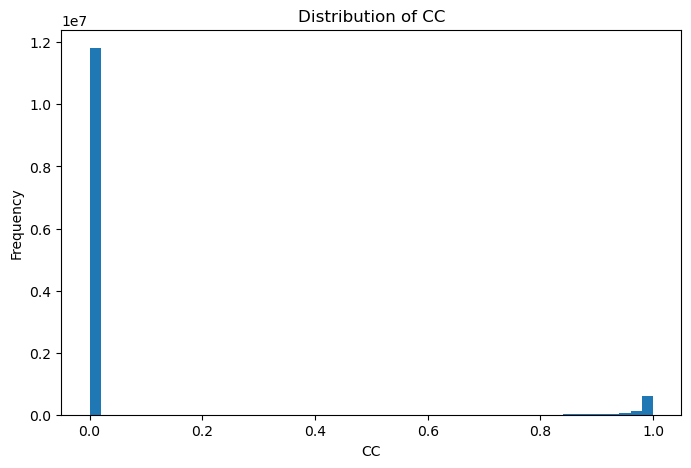

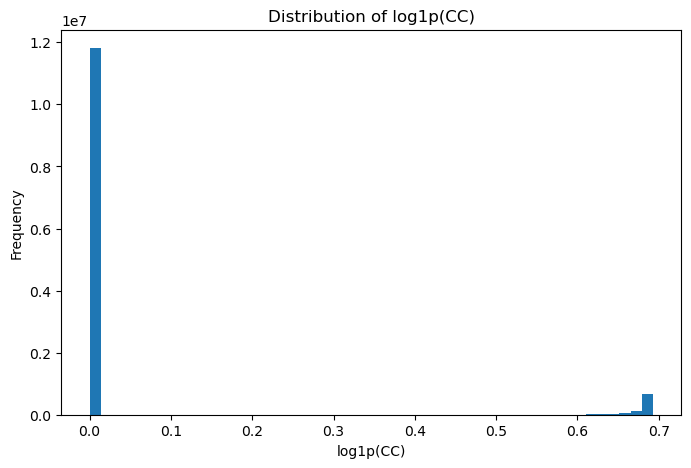

In [17]:
import numpy as np

if TASK_TYPE == "binary":
    pos = float(y_train.sum())
    neg = float(y_train.size - y_train.sum())

    print("Positive pixels:", pos)
    print("Negative pixels:", neg)
    print("Positive ratio:", pos / (pos + neg))
    print("Negative ratio:", neg / (pos + neg))

    pos = y_train.sum()
    neg = y_train.size - pos

    plt.bar(["Negative", "Positive"], [neg, pos])
    plt.title("Class Distribution in Training Data")
    plt.ylabel("Number of Pixels")
    plt.show()

elif TASK_TYPE in ["regression", "CC_regression"]:
    analyze_regression_target(y_train, name=TARGET, show_log=True)
    

# Pipeline - binary (is_heatwave) and non-binary (CC, ID, OD) target prediction

## ConvLSTM

In [18]:
class NumpySeqDataset(Dataset):
    # wraps numpy arrays into a PyTorch Dataset for easy batching
    def __init__(self, X, y):
        self.X = torch.from_numpy(X).float()  # (N - samples, L - frames/time steps, C - number of channels per frame, H - height, W - width)
        self.y = torch.from_numpy(y).float()  # (N labels, 1, H, W) - target is heatwave next day (binary mask - Y/N)
    def __len__(self): return self.X.shape[0]
    def __getitem__(self, i): return self.X[i], self.y[i]

class ConvLSTMCell(nn.Module):
    # standard LSTM cell but with convolutional gates instead of linear (standard LSTM does fully connected gates, ConvLSTM does convolutional gates to preserve spatial structure)
    # we do it to keep the spatial relationships between neighboring cells 
    def __init__(self, input_dim, hidden_dim, kernel_size=3):
        super().__init__()
        padding = kernel_size // 2
        self.hidden_dim = hidden_dim
        self.conv = nn.Conv2d(input_dim + hidden_dim, 4 * hidden_dim,
                              kernel_size=kernel_size, padding=padding)
        # LSTM uses matrix multiplication to compute gates, we replace it with 2D convolution to preserve spatial structure, the hidden state remains a spatial feature map instead of collapsing space into a vector

    def forward(self, x, h, c):
        # x: (B, Cin, H, W), h/c: (B, Chid, H, W)
        combined = torch.cat([x, h], dim=1) # x and h are concatenated along the channel dimension to form the input to the convolutional gates 
        # x is the current input frame (with all channels), h is the previous hidden state (also a feature map), it carries information from previous time steps, by concatenating them we allow the gates to compute based on both current input and past hidden state
        gates = self.conv(combined)
        i, f, o, g = torch.chunk(gates, 4, dim=1)
        i = torch.sigmoid(i) # how much of new info to write into memory
        f = torch.sigmoid(f) # how much of old memory to keep
        o = torch.sigmoid(o) # how much of memory to expose as hidden state
        g = torch.tanh(g) # candidate new memory content
        c_next = f * c + i * g
        h_next = o * torch.tanh(c_next)
        return h_next, c_next

class ConvLSTM(nn.Module):
    def __init__(self, input_dim, hidden_dim=32, kernel_size=3):
        """
        task_type:
            - 'binary'        -> returns raw logits for BCEWithLogitsLoss
            - 'regression'    -> returns unbounded output for ID / OD prediction
            - 'CC_regression' -> returns sigmoid-bounded output in [0,1]
        """
        super().__init__()
        self.cell = ConvLSTMCell(input_dim, hidden_dim, kernel_size)
        self.head = nn.Conv2d(hidden_dim, 1, kernel_size=1)

        if TASK_TYPE not in ["binary", "regression", "CC_regression"]:
            raise ValueError("task_type must be 'binary' or 'regression' or 'CC_regression'")

    def forward(self, x):
        # x: (B, L, C, H, W)
        B, L, C, H, W = x.shape
        h = torch.zeros(B, self.cell.hidden_dim, H, W, device=x.device)
        c = torch.zeros(B, self.cell.hidden_dim, H, W, device=x.device)

        for t in range(L):
            h, c = self.cell(x[:, t], h, c)

        out = self.head(h)  # (B, 1, H, W)

        if TASK_TYPE == "binary":
            # raw logits, because BCEWithLogitsLoss expects logits
            return out

        elif TASK_TYPE == "regression":
            # unbounded output for ID / OD values
            return out

        elif TASK_TYPE == "CC_regression":
            # bounded output for CC prediction in [0,1]
            return torch.sigmoid(out)

## Define the type of model and data


In [22]:
device = "cuda" if torch.cuda.is_available() else "cpu"

train_ds = NumpySeqDataset(X_train_n, y_train_p)
val_ds   = NumpySeqDataset(X_val_n, y_val_p)
test_ds  = NumpySeqDataset(X_test_n, y_test_p)

train_loader = DataLoader(train_ds, batch_size=8, shuffle=True)
val_loader   = DataLoader(val_ds, batch_size=8, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=8, shuffle=False)


# pos_weight = (#neg / #pos) over training pixels
pos = float(y_train_p.sum())
neg = float(y_train_p.size - y_train_p.sum())
pos_weight = torch.tensor([neg / (pos + 1e-6)], device=device)

if TASK_TYPE == "binary":
    model = ConvLSTM(
    input_dim=len(COEFFS),
    hidden_dim=32,
    kernel_size=3
        ).to(device)
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

elif TASK_TYPE == "CC_regression":
    model = ConvLSTM(
    input_dim=X_train_n.shape[2],
    hidden_dim=32,
    kernel_size=3
        ).to(device)
    criterion = nn.MSELoss()

elif TASK_TYPE == "regression":   # for ID / OD
    model = ConvLSTM(
        input_dim=X_train_n.shape[2],
        hidden_dim=32,
        kernel_size=3,
    ).to(device)
    # criterion = nn.MSELoss()   # or SmoothL1Loss later
    criterion = nn.SmoothL1Loss()



opt = torch.optim.Adam(model.parameters(), lr=1e-3)

def evaluate(loader):
    model.eval()
    losses = []
    with torch.no_grad():
        for Xb, yb in loader:
            Xb, yb = Xb.to(device), yb.to(device)
            logits = model(Xb) # for regression it should be preds 
            loss = criterion(logits, yb)
            losses.append(loss.item())
    return float(np.mean(losses))
    

## Training 

In [23]:
for epoch in range(1, 11):
    model.train()
    for Xb, yb in train_loader:
        Xb, yb = Xb.to(device), yb.to(device)
        opt.zero_grad()
        logits = model(Xb) # for regression it should be preds
        loss = criterion(logits, yb)
        loss.backward()
        opt.step()

    val_loss = evaluate(val_loader)
    print(f"Epoch {epoch:02d} | val_loss={val_loss:.4f}")

Epoch 01 | val_loss=0.0530
Epoch 02 | val_loss=0.0491
Epoch 03 | val_loss=0.0478
Epoch 04 | val_loss=0.0468
Epoch 05 | val_loss=0.0471
Epoch 06 | val_loss=0.0479
Epoch 07 | val_loss=0.0473
Epoch 08 | val_loss=0.0469
Epoch 09 | val_loss=0.0478
Epoch 10 | val_loss=0.0472


## Evaluation metrics

In [24]:
def get_preds_and_targets(model, loader, device, apply_sigmoid=True):
    """
    Returns:
        pred_prob: (N, 1, H, W)
        true:      (N, 1, H, W)
    """
    model.eval()
    all_pred = []
    all_true = []

    with torch.no_grad():
        for Xb, yb in loader:
            Xb = Xb.to(device)
            logits = model(Xb)

            if apply_sigmoid:
                probs = torch.sigmoid(logits).cpu().numpy()
            else:
                probs = logits.cpu().numpy()

            all_pred.append(probs)
            all_true.append(yb.numpy())

    pred_prob = np.concatenate(all_pred, axis=0)
    true = np.concatenate(all_true, axis=0)
    return pred_prob, true


def compute_binary_metrics(y_true_bin, y_pred_bin, y_prob):
    """
    Inputs are flattened 1D arrays.
    """
    f1 = f1_score(y_true_bin, y_pred_bin, zero_division=0)
    precision = precision_score(y_true_bin, y_pred_bin, zero_division=0)
    recall = recall_score(y_true_bin, y_pred_bin, zero_division=0)

    intersection = np.logical_and(y_true_bin, y_pred_bin).sum()
    union = np.logical_or(y_true_bin, y_pred_bin).sum()
    iou = intersection / (union + 1e-6)

    pr_auc = average_precision_score(y_true_bin, y_prob)

    # ROC-AUC can fail if only one class is present
    
    roc_auc = roc_auc_score(y_true_bin, y_prob)

    # tn = np.logical_and(y_true_bin == 0, y_pred_bin == 0).sum()      
    # fp = np.logical_and(y_true_bin == 0, y_pred_bin == 1).sum()
    # specificity = tn / (tn + fp + 1e-6)

    brier = np.mean((y_prob - y_true_bin) ** 2)

    return {
        "f1": float(f1),
        "precision": float(precision),
        "recall": float(recall),
        "iou": float(iou),
        "pr_auc": float(pr_auc),
        "roc_auc": float(roc_auc) if not np.isnan(roc_auc) else np.nan,
        "brier": float(brier),
    }

def compute_non_binary_metrics(y_true_bin, y_prob):
    """
    For metrics that don't require a binary threshold (e.g. ROC-AUC, PR-AUC, Brier).
    """
    rmse = np.sqrt(np.mean((y_prob - y_true_bin) ** 2))
    r_squared = 1 - np.sum((y_true_bin - y_prob) ** 2) / np.sum((y_true_bin - np.mean(y_true_bin)) ** 2)
    mae = np.mean(np.abs(y_prob - y_true_bin))
    pearson_corr = np.corrcoef(y_true_bin, y_prob)[0, 1]

    return {
        "rmse": float(rmse),
        "r_squared": float(r_squared),
        "mae": float(mae),
        "pearson_corr": float(pearson_corr),
    }

# def compute_non_binary_metrics(y_true, y_pred):
#     rmse = np.sqrt(np.mean((y_pred - y_true) ** 2))
#     mae = np.mean(np.abs(y_pred - y_true))

#     denom = np.sum((y_true - np.mean(y_true)) ** 2)
#     if denom < 1e-12:
#         r_squared = np.nan
#     else:
#         r_squared = 1 - np.sum((y_true - y_pred) ** 2) / denom

#     if np.std(y_true) < 1e-12 or np.std(y_pred) < 1e-12:
#         pearson_corr = np.nan
#     else:
#         pearson_corr = np.corrcoef(y_true, y_pred)[0, 1]

#     return {
#         "rmse": float(rmse),
#         "r_squared": float(r_squared) if not np.isnan(r_squared) else np.nan,
#         "mae": float(mae),
#         "pearson_corr": float(pearson_corr) if not np.isnan(pearson_corr) else np.nan,
#     }

## Find best threshold for each model

In [25]:
def find_best_threshold(y_true, y_prob, metric="f1", thresholds=None):
    """
    y_true: original target array, shape (N, 1, H, W) or similar
    y_prob: predicted probabilities, same shape
    """
    if thresholds is None:
        thresholds = np.linspace(0.05, 0.95, 91)

    y_true_bin = (y_true >= 0.5).astype(np.uint8).ravel()
    y_prob_flat = y_prob.ravel()

    best_thr = None
    best_score = -np.inf
    best_metrics = None

    for thr in thresholds:
        y_pred_bin = (y_prob_flat >= thr).astype(np.uint8)
        metrics = compute_binary_metrics(y_true_bin, y_pred_bin, y_prob_flat)
     

        score = metrics[metric]
        if score > best_score:
            best_score = score
            best_thr = float(thr)
            best_metrics = metrics

    return best_thr, best_score, best_metrics

#### It is important to find the best threshold, since the dataset is very imbalanced, mostly it is background pixels, not heatwave ones. The threshold tuning just converts that ranking into a better binary mask. 

In [26]:
def evaluate_experiment(
    model,
    val_loader,
    test_loader,
    device,
    experiment_name,
    input_features,
    target_name,
    threshold_metric="f1",
):
    # ---------------------------------
    # decide automatically how to postprocess model outputs
    # ---------------------------------
    if TASK_TYPE == "binary":
        apply_sigmoid = True   # model returns logits
    else:
        apply_sigmoid = False  # regression models should already return final values

    # ---------------------------------
    # get predictions
    # ---------------------------------
    val_pred, val_true = get_preds_and_targets(model, val_loader, device, apply_sigmoid=apply_sigmoid)
    test_pred, test_true = get_preds_and_targets(model, test_loader, device, apply_sigmoid=apply_sigmoid)

    # =================================
    # BINARY TASK
    # =================================
    if TASK_TYPE == "binary":
        best_thr, best_val_score, val_metrics_at_best = find_best_threshold(
            val_true, val_pred, metric=threshold_metric
        )

        y_true = (test_true >= 0.5).astype(np.uint8).ravel()
        y_prob = test_pred.ravel()
        y_pred = (y_prob >= best_thr).astype(np.uint8)

        test_metrics = compute_binary_metrics(y_true, y_pred, y_prob)

        result = {
            "experiment": experiment_name,
            "inputs": ", ".join(input_features) if isinstance(input_features, (list, tuple)) else str(input_features),
            "target": target_name,
            "task_type": TASK_TYPE,
            "threshold_metric": threshold_metric,
            "best_val_threshold": float(best_thr),
            f"best_val_{threshold_metric}": float(best_val_score),

            "val_f1": val_metrics_at_best["f1"],
            "val_iou": val_metrics_at_best["iou"],
            "val_precision": val_metrics_at_best["precision"],
            "val_recall": val_metrics_at_best["recall"],
            "val_pr_auc": val_metrics_at_best["pr_auc"],
            "val_roc_auc": val_metrics_at_best["roc_auc"],
            "val_brier": val_metrics_at_best["brier"],

            "test_f1": test_metrics["f1"],
            "test_iou": test_metrics["iou"],
            "test_precision": test_metrics["precision"],
            "test_recall": test_metrics["recall"],
            "test_pr_auc": test_metrics["pr_auc"],
            "test_roc_auc": test_metrics["roc_auc"],
            "test_brier": test_metrics["brier"],
        }

        return result, test_pred, test_true, best_thr

    # =================================
    # REGRESSION TASKS: CC and ID / OD
    # =================================
    else:
        y_val_true = val_true.ravel()
        y_val_pred = val_pred.ravel()

        y_test_true = test_true.ravel()
        y_test_pred = test_pred.ravel()

        # For ID / OD regression, convert back from log-space
        if TASK_TYPE == "regression":
            y_val_true_eval = np.expm1(y_val_true)
            # y_val_pred_eval = np.expm1(y_val_pred)

            y_test_true_eval = np.expm1(y_test_true)
            # y_test_pred_eval = np.expm1(y_test_pred)

            y_val_pred_eval = np.maximum(np.expm1(y_val_pred), 0.0)
            y_test_pred_eval = np.maximum(np.expm1(y_test_pred), 0.0)

        # For CC regression, use outputs directly
        elif TASK_TYPE == "CC_regression":
            y_val_true_eval = y_val_true
            y_val_pred_eval = y_val_pred

            y_test_true_eval = y_test_true
            y_test_pred_eval = y_test_pred

        val_metrics = compute_non_binary_metrics(y_val_true_eval, y_val_pred_eval)
        test_metrics = compute_non_binary_metrics(y_test_true_eval, y_test_pred_eval)


        # DEBUG CHECK: mean and std
        # -----------------------------
        # print(f"\n[DEBUG] {experiment_name}")
        # print("Validation target mean:", y_val_true_eval.mean())
        # print("Validation target std:", y_val_true_eval.std())
        # print("Validation pred mean:", y_val_pred_eval.mean())
        # print("Validation pred std:", y_val_pred_eval.std())

        # print("Test target mean:", y_test_true_eval.mean())
        # print("Test target std:", y_test_true_eval.std())
        # print("Test pred mean:", y_test_pred_eval.mean())
        # print("Test pred std:", y_test_pred_eval.std())

        result = {
            "experiment": experiment_name,
            "inputs": ", ".join(input_features) if isinstance(input_features, (list, tuple)) else str(input_features),
            "target": target_name,
            "task_type": TASK_TYPE,

            "val_rmse": val_metrics["rmse"],
            "val_r_squared": val_metrics["r_squared"],
            "val_mae": val_metrics["mae"],
            "val_pearson_corr": val_metrics["pearson_corr"],

            "test_rmse": test_metrics["rmse"],
            "test_r_squared": test_metrics["r_squared"],
            "test_mae": test_metrics["mae"],
            "test_pearson_corr": test_metrics["pearson_corr"],
        }

        return result, y_test_pred_eval.reshape(test_pred.shape), y_test_true_eval.reshape(test_true.shape), None

In [27]:
def append_result_to_csv(result_dict, csv_path="ablation_results.csv"):
    df_new = pd.DataFrame([result_dict])

    if os.path.exists(csv_path):
        df_old = pd.read_csv(csv_path)
        df_all = pd.concat([df_old, df_new], ignore_index=True)
    else:
        df_all = df_new

    df_all.to_csv(csv_path, index=False)
    return df_all

In [28]:
# example names
experiment_name = "dc_bc_id_od_hw_ERA5_to_cc_scandi_2018" # change experiment name for each run to keep track of different ablations
input_features = COEFFS # change input features description based on the ablation (e.g. if you remove some coeffs, update this list accordingly)
target_name = TARGET  # change target name if you change the target variable in the dataset (e.g. if you switch to regression and predict CC, update this accordingly)

result, pred, true, best_thr = evaluate_experiment(
    model=model,
    val_loader=val_loader,
    test_loader=test_loader,
    device=device,
    experiment_name=experiment_name,
    input_features=input_features,
    target_name=target_name,
    threshold_metric="f1",
)

print(result)

df_all = append_result_to_csv(result, csv_path="ablation_results.csv")
print(df_all.tail())

{'experiment': 'dc_bc_id_od_hw_ERA5_to_cc_scandi_2018', 'inputs': 'BC, DC, ID, OD, is_heatwave, swvl1, land_mask, u, v, z', 'target': 'CC', 'task_type': 'CC_regression', 'val_rmse': 0.21158629655838013, 'val_r_squared': 0.48027217388153076, 'val_mae': 0.07791373133659363, 'val_pearson_corr': 0.695777898111157, 'test_rmse': 0.23748524487018585, 'test_r_squared': 0.5768343210220337, 'test_mae': 0.1045307070016861, 'test_pearson_corr': 0.760707199766995}
                                 experiment  \
20         dc_bc_id_od_cc_ERA5_to_hw_iberia   
21    dc_bc_id_od_cc_ERA5_to_hw_iberia_2010   
22    dc_bc_id_od_hw_ERA5_to_cc_iberia_2010   
23  dc_bc_id_od_cc_ERA5_to_hw_mediterranean   
24    dc_bc_id_od_hw_ERA5_to_cc_scandi_2018   

                                               inputs       target  \
20      BC, DC, ID, OD, CC, swvl1, land_mask, u, v, z  is_heatwave   
21      BC, DC, ID, OD, CC, swvl1, land_mask, u, v, z  is_heatwave   
22  BC, DC, ID, OD, is_heatwave, swvl1, land_mask,.

In [29]:
print("Train mean:", y_train.mean(), "std:", y_train.std(), "min:", y_train.min(), "max:", y_train.max())
print("Val mean:", y_val.mean(), "std:", y_val.std(), "min:", y_val.min(), "max:", y_val.max())
print("Test mean:", y_test.mean(), "std:", y_test.std(), "min:", y_test.min(), "max:", y_test.max())

Train mean: 0.06927535 std: 0.2505596 min: 0.0 max: 1.0
Val mean: 0.10008056 std: 0.29349422 min: 0.0 max: 1.0
Test mean: 0.16435634 std: 0.36507446 min: 0.0 max: 1.0


## Visualise the predictions 

## incorporate NUTS 2 grid

In [30]:
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd

# ----------------------------
# 1. Load NUTS-2 boundaries
# ----------------------------
# Better for your 2003 case study:
# nuts2 = gpd.read_file("NUTS_RG_01M_2003_4326_LEVL_2.geojson")
nuts2 = gpd.read_file("NUTS_RG_01M_2024_4326_LEVL_2.geojson")

nuts2 = nuts2.to_crs("EPSG:4326")  # ensure it's in lat/lon


# Iberia only
# nuts2_ib = nuts2[nuts2["CNTR_CODE"].isin(["ES", "PT"])].copy()

# For Mediterranean Basin 
# med_countries = ["ES", "PT", "FR", "IT", "GR", "HR", "SI", "MT", "CY"]
# nuts2_med = nuts2[nuts2["CNTR_CODE"].isin(med_countries)].copy()

In [31]:
target_date = np.datetime64("2018-07-27")
idx = np.where(test_dates == target_date)[0][0]

pred_map = pred[idx, 0]   # prediction map
true_map = true[idx, 0]   # true target map

lats = y_ib.lat.values
lons = y_ib.lon.values

def plot_mask_lonlat(mask, title, nuts_overlay=None, vmin=None, vmax=None,
                     boundary_color="black", boundary_lw=0.6):
    fig, ax = plt.subplots(figsize=(10, 4))

    # heatmap
    mesh = ax.pcolormesh(
        lons, lats, mask,
        shading="auto",
        vmin=vmin,
        vmax=vmax
    )

    # overlay NUTS-2 boundaries
    if nuts_overlay is not None:
        nuts_overlay.boundary.plot(
            ax=ax,
            color=boundary_color,
            linewidth=boundary_lw
        )

    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.set_title(title)

    # keep geographic aspect approximately correct
    lat_mean = np.mean(lats)
    ax.set_aspect(1 / np.cos(np.deg2rad(lat_mean)))
    ax.set_xlim(lons.min(), lons.max())
    ax.set_ylim(lats.min(), lats.max())
    plt.colorbar(mesh, ax=ax)
    plt.show()

### 27.07.2018


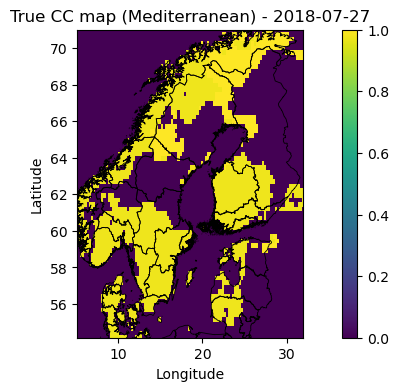

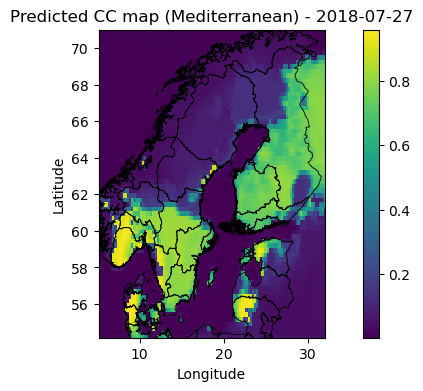

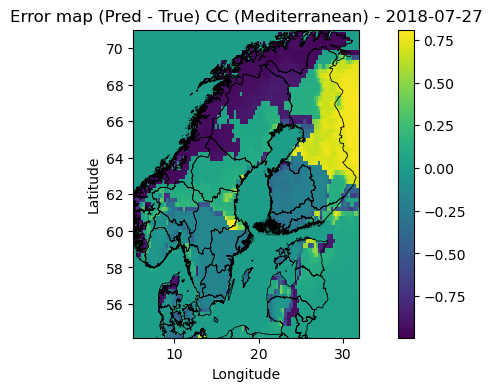

In [32]:
# Find index of target date
target_date = np.datetime64("2018-07-27")
idx = np.where(test_dates == target_date)[0][0]

pred_map = pred[idx, 0]   # prediction map
true_map = true[idx, 0]   # true target map

lats = y_ib.lat.values
lons = y_ib.lon.values

# def plot_mask_lonlat(mask, title, vmin=None, vmax=None):
#     plt.figure(figsize=(10, 4))  # wider figure

#     plt.pcolormesh(lons, lats, mask, shading="auto", vmin=vmin, vmax=vmax)

#     plt.xlabel("Longitude")
#     plt.ylabel("Latitude")
#     plt.title(title)
#     plt.colorbar()
#     lat_mean = np.mean(lats)
#     plt.gca().set_aspect(1 / np.cos(np.deg2rad(lat_mean)))

#     plt.show()

if TASK_TYPE == "binary":
    prob_map = pred_map
    bin_map = (prob_map >= best_thr).astype(int)
    err_map = bin_map - true_map

    plot_mask_lonlat(true_map, f"True heatwave mask (Mediterranean) - {str(target_date)}", nuts_overlay=nuts2)
    plot_mask_lonlat(bin_map, f"Predicted heatwave mask (Mediterranean) - {str(target_date)}", nuts_overlay=nuts2)
    plot_mask_lonlat(prob_map, f"Predicted probability (Mediterranean) - {str(target_date)}", nuts_overlay=nuts2)
    plot_mask_lonlat(err_map, f"Error map (Pred - True) (Mediterranean) - {str(target_date)}", nuts_overlay=nuts2)

elif TASK_TYPE == "CC_regression":
    err_map = pred_map - true_map

    plot_mask_lonlat(true_map, f"True CC map (Mediterranean) - {str(target_date)}", nuts_overlay=nuts2)
    plot_mask_lonlat(pred_map, f"Predicted CC map (Mediterranean) - {str(target_date)}", nuts_overlay=nuts2)
    plot_mask_lonlat(err_map, f"Error map (Pred - True) CC (Mediterranean) - {str(target_date)}", nuts_overlay=nuts2)

elif TASK_TYPE == "regression":
    err_map = pred_map - true_map

    plot_mask_lonlat(true_map, f"True ID/OD map (Mediterranean) - {str(target_date)}", nuts_overlay=nuts2)
    plot_mask_lonlat(pred_map, f"Predicted ID/OD map (Mediterranean) - {str(target_date)}", nuts_overlay=nuts2)
    plot_mask_lonlat(err_map, f"Error map (Pred - True) ID/OD (Mediterranean) - {str(target_date)}", nuts_overlay=nuts2)

### 1.08.2018

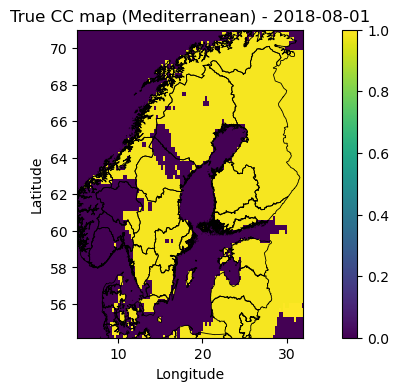

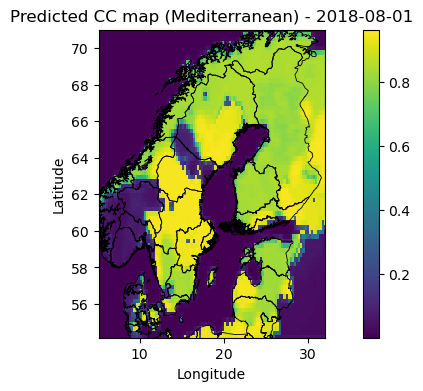

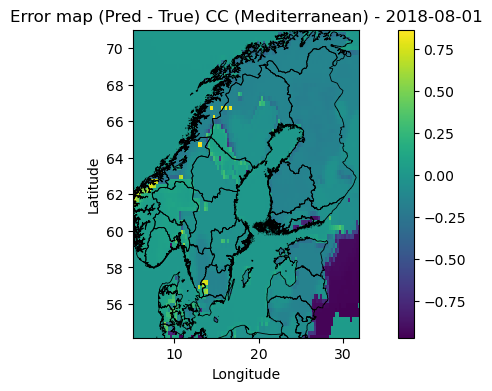

In [33]:
# Find index of target date
target_date = np.datetime64("2018-08-01")
idx = np.where(test_dates == target_date)[0][0]

pred_map = pred[idx, 0]   # prediction map
true_map = true[idx, 0]   # true target map

lats = y_ib.lat.values
lons = y_ib.lon.values

if TASK_TYPE == "binary":
    prob_map = pred_map
    bin_map = (prob_map >= best_thr).astype(int)
    err_map = bin_map - true_map

    plot_mask_lonlat(true_map, f"True heatwave mask (Mediterranean) - {str(target_date)}", nuts_overlay=nuts2)
    plot_mask_lonlat(bin_map, f"Predicted heatwave mask (Mediterranean) - {str(target_date)}", nuts_overlay=nuts2)
    plot_mask_lonlat(prob_map, f"Predicted probability (Mediterranean) - {str(target_date)}", nuts_overlay=nuts2)
    plot_mask_lonlat(err_map, f"Error map (Pred - True) (Mediterranean) - {str(target_date)}", nuts_overlay=nuts2)

elif TASK_TYPE == "CC_regression":
    err_map = pred_map - true_map

    plot_mask_lonlat(true_map, f"True CC map (Mediterranean) - {str(target_date)}", nuts_overlay=nuts2)
    plot_mask_lonlat(pred_map, f"Predicted CC map (Mediterranean) - {str(target_date)}", nuts_overlay=nuts2)
    plot_mask_lonlat(err_map, f"Error map (Pred - True) CC (Mediterranean) - {str(target_date)}", nuts_overlay=nuts2)

elif TASK_TYPE == "regression":
    err_map = pred_map - true_map

    plot_mask_lonlat(true_map, f"True ID/OD map (Mediterranean) - {str(target_date)}", nuts_overlay=nuts2)
    plot_mask_lonlat(pred_map, f"Predicted ID/OD map (Mediterranean) - {str(target_date)}", nuts_overlay=nuts2)
    plot_mask_lonlat(err_map, f"Error map (Pred - True) ID/OD (Mediterranean) - {str(target_date)}", nuts_overlay=nuts2)

### 5.08.2018

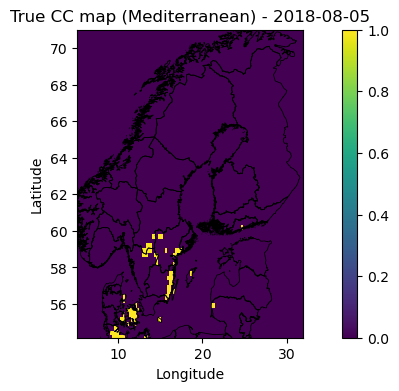

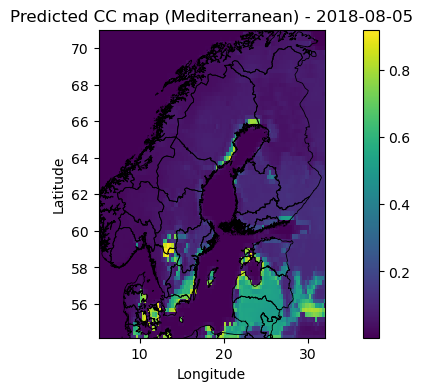

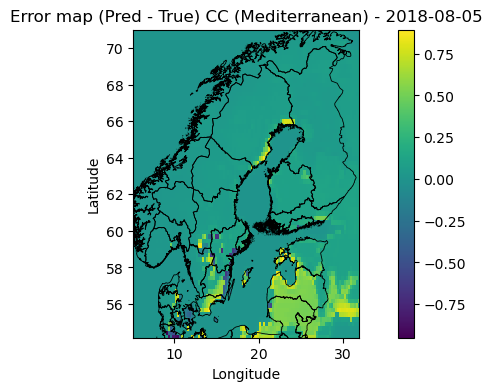

In [34]:
# Find index of target date
target_date = np.datetime64("2018-08-05")
idx = np.where(test_dates == target_date)[0][0]

pred_map = pred[idx, 0]   # prediction map
true_map = true[idx, 0]   # true target map

lats = y_ib.lat.values
lons = y_ib.lon.values

if TASK_TYPE == "binary":
    prob_map = pred_map
    bin_map = (prob_map >= best_thr).astype(int)
    err_map = bin_map - true_map

    plot_mask_lonlat(true_map, f"True heatwave mask (Mediterranean) - {str(target_date)}", nuts_overlay=nuts2)
    plot_mask_lonlat(bin_map, f"Predicted heatwave mask (Mediterranean) - {str(target_date)}", nuts_overlay=nuts2)
    plot_mask_lonlat(prob_map, f"Predicted probability (Mediterranean) - {str(target_date)}", nuts_overlay=nuts2)
    plot_mask_lonlat(err_map, f"Error map (Pred - True) (Mediterranean) - {str(target_date)}", nuts_overlay=nuts2)

elif TASK_TYPE == "CC_regression":
    err_map = pred_map - true_map

    plot_mask_lonlat(true_map, f"True CC map (Mediterranean) - {str(target_date)}", nuts_overlay=nuts2)
    plot_mask_lonlat(pred_map, f"Predicted CC map (Mediterranean) - {str(target_date)}", nuts_overlay=nuts2)
    plot_mask_lonlat(err_map, f"Error map (Pred - True) CC (Mediterranean) - {str(target_date)}", nuts_overlay=nuts2)

elif TASK_TYPE == "regression":
    err_map = pred_map - true_map

    plot_mask_lonlat(true_map, f"True ID/OD map (Mediterranean) - {str(target_date)}", nuts_overlay=nuts2)
    plot_mask_lonlat(pred_map, f"Predicted ID/OD map (Mediterranean) - {str(target_date)}", nuts_overlay=nuts2)
    plot_mask_lonlat(err_map, f"Error map (Pred - True) ID/OD (Mediterranean) - {str(target_date)}", nuts_overlay=nuts2)

### 10.08.2018

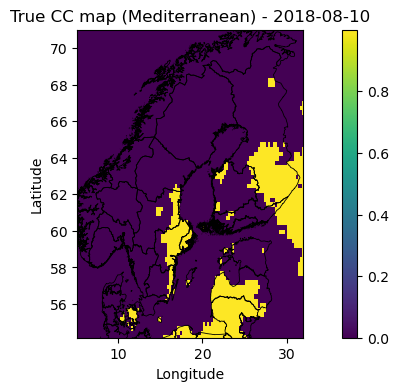

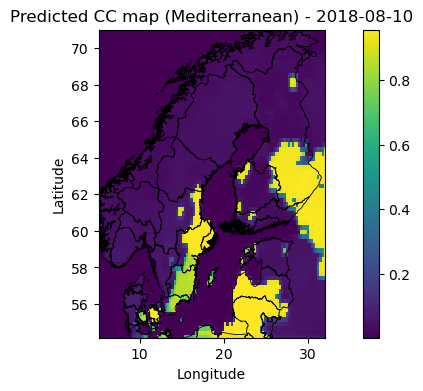

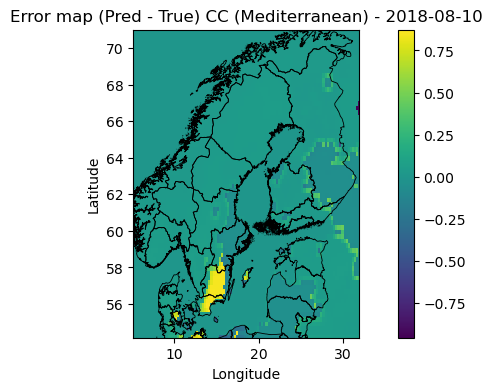

In [35]:
# Find index of target date
target_date = np.datetime64("2018-08-10")
idx = np.where(test_dates == target_date)[0][0]

pred_map = pred[idx, 0]   # prediction map
true_map = true[idx, 0]   # true target map

lats = y_ib.lat.values
lons = y_ib.lon.values

if TASK_TYPE == "binary":
    prob_map = pred_map
    bin_map = (prob_map >= best_thr).astype(int)
    err_map = bin_map - true_map

    plot_mask_lonlat(true_map, f"True heatwave mask (Mediterranean) - {str(target_date)}", nuts_overlay=nuts2)
    plot_mask_lonlat(bin_map, f"Predicted heatwave mask (Mediterranean) - {str(target_date)}", nuts_overlay=nuts2)
    plot_mask_lonlat(prob_map, f"Predicted probability (Mediterranean) - {str(target_date)}", nuts_overlay=nuts2)
    plot_mask_lonlat(err_map, f"Error map (Pred - True) (Mediterranean) - {str(target_date)}", nuts_overlay=nuts2)

elif TASK_TYPE == "CC_regression":
    err_map = pred_map - true_map

    plot_mask_lonlat(true_map, f"True CC map (Mediterranean) - {str(target_date)}", nuts_overlay=nuts2)
    plot_mask_lonlat(pred_map, f"Predicted CC map (Mediterranean) - {str(target_date)}", nuts_overlay=nuts2)
    plot_mask_lonlat(err_map, f"Error map (Pred - True) CC (Mediterranean) - {str(target_date)}", nuts_overlay=nuts2)

elif TASK_TYPE == "regression":
    err_map = pred_map - true_map

    plot_mask_lonlat(true_map, f"True ID/OD map (Mediterranean) - {str(target_date)}", nuts_overlay=nuts2)
    plot_mask_lonlat(pred_map, f"Predicted ID/OD map (Mediterranean) - {str(target_date)}", nuts_overlay=nuts2)
    plot_mask_lonlat(err_map, f"Error map (Pred - True) ID/OD (Mediterranean) - {str(target_date)}", nuts_overlay=nuts2)

### 15.08.2018

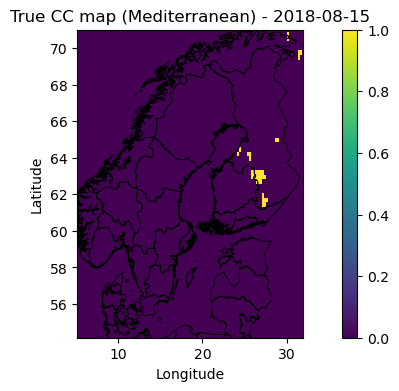

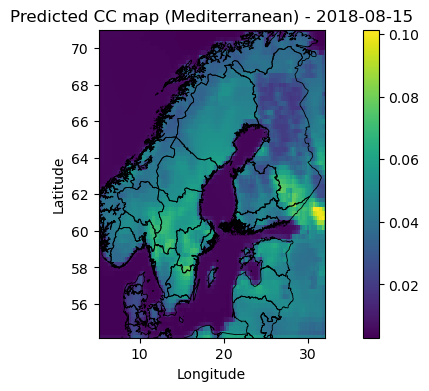

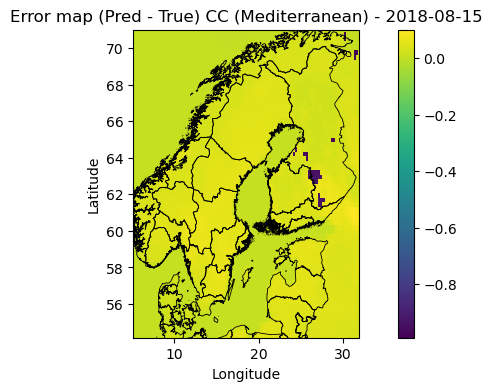

: 

In [ ]:
# Find index of target date
target_date = np.datetime64("2018-08-15")
idx = np.where(test_dates == target_date)[0][0]

pred_map = pred[idx, 0]   # prediction map
true_map = true[idx, 0]   # true target map

lats = y_ib.lat.values
lons = y_ib.lon.values

if TASK_TYPE == "binary":
    prob_map = pred_map
    bin_map = (prob_map >= best_thr).astype(int)
    err_map = bin_map - true_map

    plot_mask_lonlat(true_map, f"True heatwave mask (Mediterranean) - {str(target_date)}", nuts_overlay=nuts2)
    plot_mask_lonlat(bin_map, f"Predicted heatwave mask (Mediterranean) - {str(target_date)}", nuts_overlay=nuts2)
    plot_mask_lonlat(prob_map, f"Predicted probability (Mediterranean) - {str(target_date)}", nuts_overlay=nuts2)
    plot_mask_lonlat(err_map, f"Error map (Pred - True) (Mediterranean) - {str(target_date)}", nuts_overlay=nuts2)

elif TASK_TYPE == "CC_regression":
    err_map = pred_map - true_map

    plot_mask_lonlat(true_map, f"True CC map (Mediterranean) - {str(target_date)}", nuts_overlay=nuts2)
    plot_mask_lonlat(pred_map, f"Predicted CC map (Mediterranean) - {str(target_date)}", nuts_overlay=nuts2)
    plot_mask_lonlat(err_map, f"Error map (Pred - True) CC (Mediterranean) - {str(target_date)}", nuts_overlay=nuts2)

elif TASK_TYPE == "regression":
    err_map = pred_map - true_map

    plot_mask_lonlat(true_map, f"True ID/OD map (Mediterranean) - {str(target_date)}", nuts_overlay=nuts2)
    plot_mask_lonlat(pred_map, f"Predicted ID/OD map (Mediterranean) - {str(target_date)}", nuts_overlay=nuts2)
    plot_mask_lonlat(err_map, f"Error map (Pred - True) ID/OD (Mediterranean) - {str(target_date)}", nuts_overlay=nuts2)

So given the past 14 days, the model predicts there is an (for example) 82% chance that tomorrow this location is in heatwave. IoU compares: 

Predicted region  ∩  True region / Predicted region  ∪  True region

## Compare the results from the feature ablation (Predictors: 9 HW, 2 CC, 2 OD, 1 OD)

#### Binary classification - is_heatwave 

In [69]:
import pandas as pd

df = pd.read_csv("ablation_results.csv")

df_bin = df[df["task_type"] == "binary"]
df_reg = df[df["task_type"] != "binary"]

best_bin = df_bin.sort_values("test_f1", ascending=False).head(5)
print(best_bin[["experiment", "inputs", "target", "test_f1", "test_pr_auc", "test_roc_auc"]])

best_reg = df_reg.sort_values("test_rmse", ascending=True).head(5)
print(best_reg[["experiment", "inputs", "target", "test_rmse", "test_r_squared", "test_pearson_corr"]])

             experiment                           inputs       target  \
2       all_coeff_to_hw  DC, BC, CC, ID, OD, is_heatwave  is_heatwave   
5     dc_cc_id_od_to_hw                   DC, CC, ID, OD  is_heatwave   
6     bc_cc_id_od_to_hw                   BC, CC, ID, OD  is_heatwave   
8     bc_dc_cc_od_to_hw                   BC, DC, CC, OD  is_heatwave   
4  bc_dc_cc_id_od_to_hw               DC, BC, CC, ID, OD  is_heatwave   

    test_f1  test_pr_auc  test_roc_auc  
2  0.774061     0.792008      0.885346  
5  0.759401     0.749586      0.868565  
6  0.755370     0.742459      0.863400  
8  0.749158     0.775292      0.877777  
4  0.748148     0.747609      0.865421  
                               experiment  \
16                   dc_cc_id_od_hw_to_bc   
14                       all_coeffs_to_bc   
22  dc_bc_id_od_hw_ERA5_to_cc_iberia_2010   
18     dc_bc_id_od_hw_to_cc_mediterranean   
17     dc_bc_id_od_hw_to_cc_mediterranean   

                                            

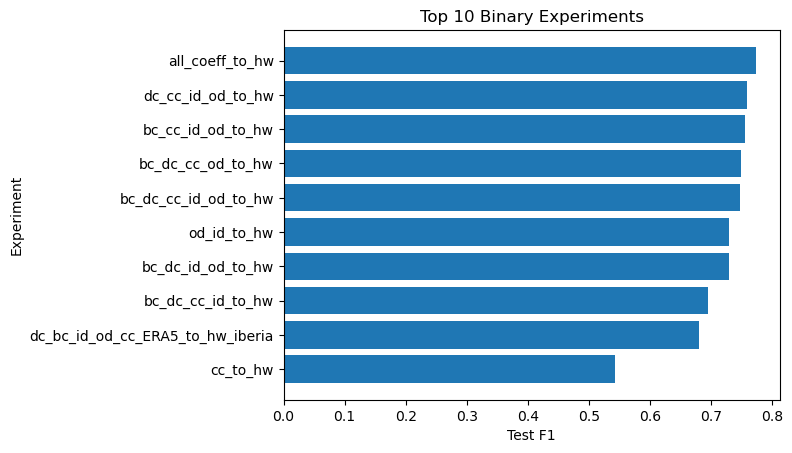

In [70]:
import matplotlib.pyplot as plt

top = df_bin.sort_values("test_f1", ascending=False).head(10)

plt.figure()
plt.barh(top["experiment"], top["test_f1"])
plt.xlabel("Test F1")
plt.ylabel("Experiment")
plt.title("Top 10 Binary Experiments")
plt.gca().invert_yaxis()
plt.show()

In [71]:
grouped = df_bin.groupby("inputs")["test_f1"].mean().sort_values(ascending=False)
print(grouped.head(10))

inputs
DC, BC, CC, ID, OD, is_heatwave                  0.774061
DC, CC, ID, OD                                   0.759401
BC, CC, ID, OD                                   0.755370
BC, DC, CC, OD                                   0.749158
DC, BC, CC, ID, OD                               0.748148
OD, ID                                           0.729836
BC, DC, ID, OD                                   0.729238
BC, DC, CC, ID                                   0.695768
BC, DC, ID, OD, CC, swvl1, land_mask, u, v, z    0.589414
CC                                               0.542638
Name: test_f1, dtype: float64


In [72]:
pivot = df.pivot_table(
    index="inputs",
    columns="target",
    values="test_f1"
)

print(pivot)

target                                         is_heatwave
inputs                                                    
BC, CC, ID, OD                                    0.755370
BC, DC, CC, ID                                    0.695768
BC, DC, CC, OD                                    0.749158
BC, DC, ID, OD                                    0.729238
BC, DC, ID, OD, CC, swvl1, land_mask, u, v, z     0.589414
CC                                                0.542638
DC, BC, CC, ID, OD                                0.748148
DC, BC, CC, ID, OD, is_heatwave                   0.774061
DC, CC, ID, OD                                    0.759401
OD, ID                                            0.729836


In [73]:
best = df_bin.loc[df_bin["test_f1"].idxmax()]

print("\nBEST EXPERIMENT:")
print(best)


BEST EXPERIMENT:
experiment                            all_coeff_to_hw
inputs                DC, BC, CC, ID, OD, is_heatwave
target                                    is_heatwave
threshold_metric                                   f1
best_val_threshold                               0.74
best_val_f1                                  0.602221
val_f1                                       0.602221
val_iou                                      0.430841
val_precision                                0.567804
val_recall                                   0.641079
val_pr_auc                                   0.638527
val_roc_auc                                  0.863771
val_brier                                    0.162087
test_f1                                      0.774061
test_iou                                     0.631403
test_precision                               0.752505
test_recall                                  0.796889
test_pr_auc                                  0.792008
test_roc_a

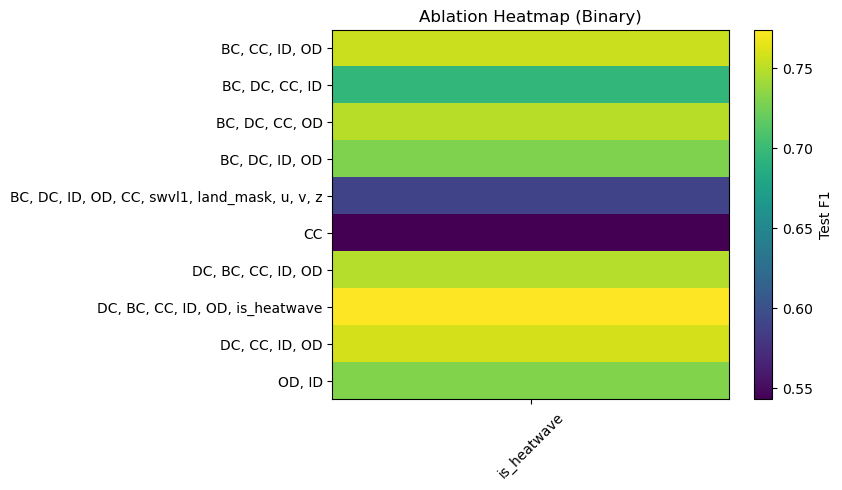

In [74]:
import matplotlib.pyplot as plt

pivot = df_bin.pivot_table(
    index="inputs",
    columns="target",
    values="test_f1"
)

plt.figure()
plt.imshow(pivot, aspect="auto")
plt.xticks(range(len(pivot.columns)), pivot.columns, rotation=45)
plt.yticks(range(len(pivot.index)), pivot.index)
plt.colorbar(label="Test F1")
plt.title("Ablation Heatmap (Binary)")
plt.show()

### Regression 

In [75]:
import pandas as pd

reg = df_reg.copy()

# Metrics where LOWER is better
for col in ["test_rmse", "test_mae"]:
    reg[col + "_norm"] = (reg[col] - reg[col].min()) / (reg[col].max() - reg[col].min())

# Metrics where HIGHER is better
for col in ["test_r_squared", "test_pearson_corr"]:
    reg[col + "_norm"] = (reg[col].max() - reg[col]) / (reg[col].max() - reg[col].min())

In [76]:
reg["overall_score"] = (
    reg["test_rmse_norm"] +
    reg["test_mae_norm"] +
    reg["test_r_squared_norm"] +
    reg["test_pearson_corr_norm"]
)

In [77]:
best_reg = reg.sort_values("overall_score").head(10)

print(best_reg[[
    "experiment", "inputs", "target",
    "test_rmse", "test_mae",
    "test_r_squared", "test_pearson_corr"
]])

                               experiment  \
12                       all_coeffs_to_cc   
3                    bc_dc_od_id_hw_to_cc   
19       dc_bc_id_od_hw_ERA5_to_cc_iberia   
17     dc_bc_id_od_hw_to_cc_mediterranean   
18     dc_bc_id_od_hw_to_cc_mediterranean   
15     dc_bc_id_od_hw_to_cc_mediterranean   
22  dc_bc_id_od_hw_ERA5_to_cc_iberia_2010   
16                   dc_cc_id_od_hw_to_bc   
1                       dc_bc_cc_hw_to_od   
14                       all_coeffs_to_bc   

                                               inputs target   test_rmse  \
12                    CC, BC, DC, ID, OD, is_heatwave     CC    0.255571   
3                         DC, BC, ID, OD, is_heatwave     CC    0.256766   
19  BC, DC, ID, OD, is_heatwave, swvl1, land_mask,...     CC    0.258800   
17                        BC, DC, ID, OD, is_heatwave     CC    0.247938   
18                        BC, DC, ID, OD, is_heatwave     CC    0.247696   
15                        BC, DC, ID, OD, is_hea

In [78]:
top = df_reg.sort_values("test_rmse").head(5)

metrics = ["test_rmse", "test_mae", "test_r_squared", "test_pearson_corr"]

for _, row in top.iterrows():
    print("\n---", row["experiment"], "---")
    for m in metrics:
        print(f"{m}: {row[m]:.4f}")


--- dc_cc_id_od_hw_to_bc ---
test_rmse: 0.0015
test_mae: 0.0006
test_r_squared: -216865.4688
test_pearson_corr: 0.2756

--- all_coeffs_to_bc ---
test_rmse: 0.0016
test_mae: 0.0005
test_r_squared: -242013.0156
test_pearson_corr: 0.1553

--- dc_bc_id_od_hw_ERA5_to_cc_iberia_2010 ---
test_rmse: 0.2083
test_mae: 0.0758
test_r_squared: 0.4169
test_pearson_corr: 0.6480

--- dc_bc_id_od_hw_to_cc_mediterranean ---
test_rmse: 0.2477
test_mae: 0.1149
test_r_squared: 0.5859
test_pearson_corr: 0.7673

--- dc_bc_id_od_hw_to_cc_mediterranean ---
test_rmse: 0.2479
test_mae: 0.1123
test_r_squared: 0.5850
test_pearson_corr: 0.7674


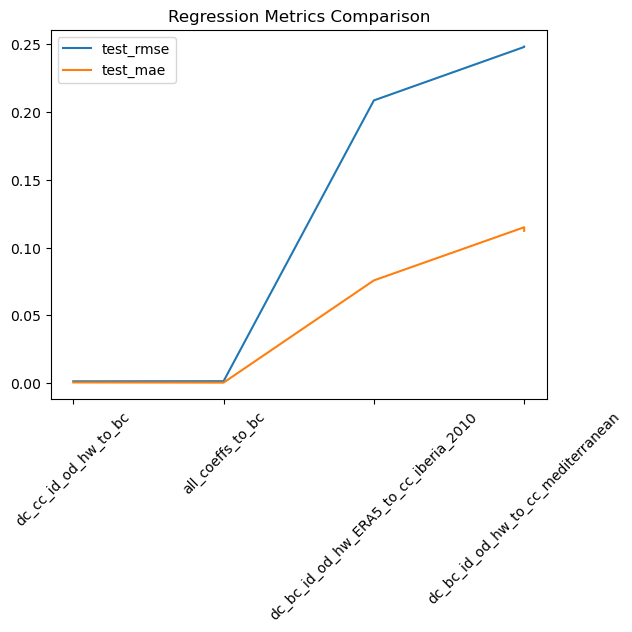

In [79]:
top = df_reg.sort_values("test_rmse").head(5)

plt.figure()

for metric in ["test_rmse", "test_mae"]:
    plt.plot(top["experiment"], top[metric], label=metric)

plt.legend()
plt.xticks(rotation=45)
plt.title("Regression Metrics Comparison")
plt.show()

#### Regression - CC, ID, OD

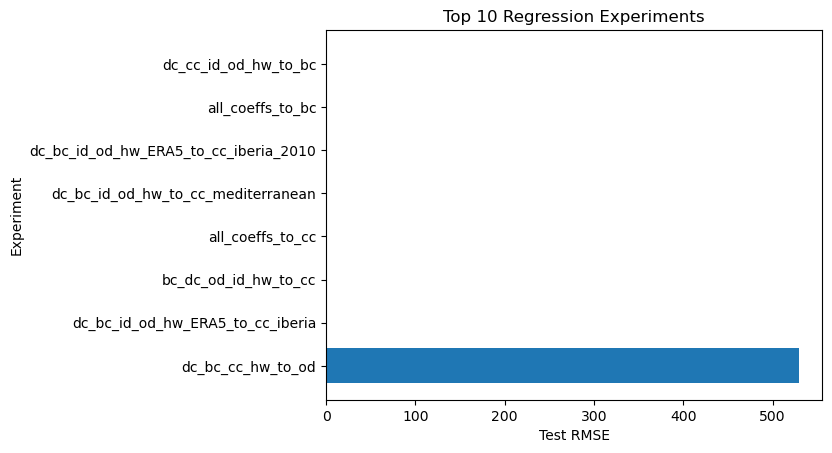

In [80]:
top = df_reg.sort_values("test_rmse").head(10)

plt.figure()
plt.barh(top["experiment"], top["test_rmse"])
plt.xlabel("Test RMSE")
plt.ylabel("Experiment")
plt.title("Top 10 Regression Experiments")
plt.gca().invert_yaxis()
plt.show()

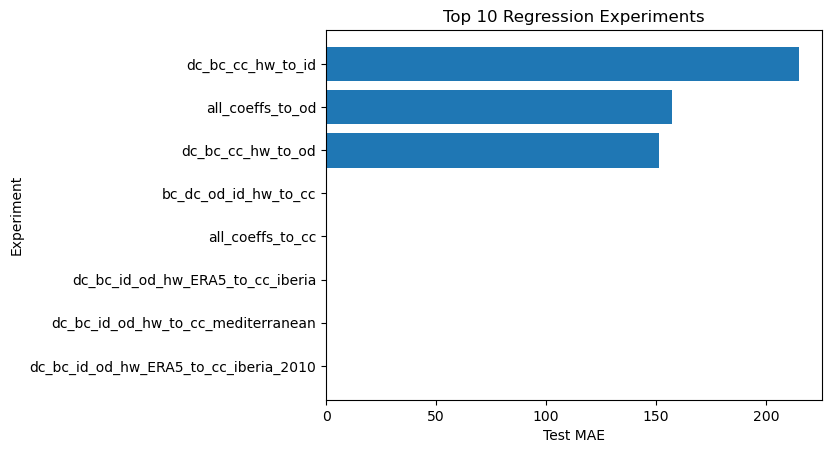

In [81]:
top = df_reg.sort_values("test_mae", ascending=False).head(10)

plt.figure()
plt.barh(top["experiment"], top["test_mae"])
plt.xlabel("Test MAE")
plt.ylabel("Experiment")
plt.title("Top 10 Regression Experiments")
plt.gca().invert_yaxis()
plt.show()

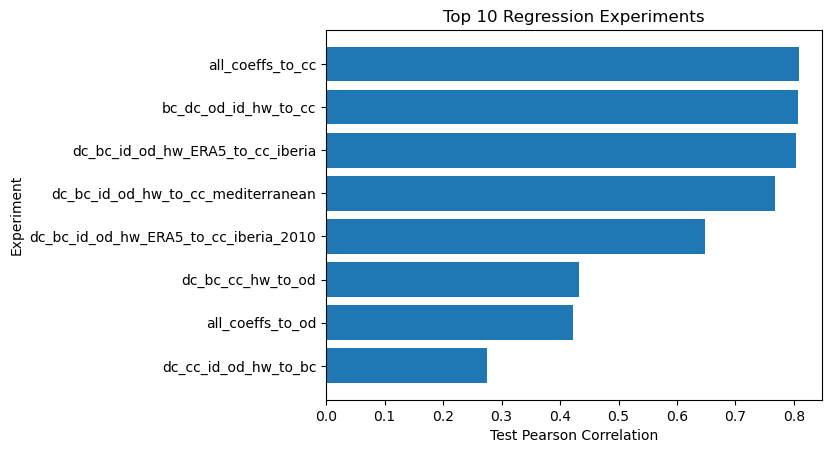

In [82]:
top = df_reg.sort_values("test_pearson_corr", ascending=False).head(10)

plt.figure()
plt.barh(top["experiment"], top["test_pearson_corr"])
plt.xlabel("Test Pearson Correlation")
plt.ylabel("Experiment")
plt.title("Top 10 Regression Experiments")
plt.gca().invert_yaxis()
plt.show()

## Proceed to this section once your target predictions is a BINARY variable

## Heatwave trajectory visualisation - for binary variable

In [70]:
dates_to_plot = [
    np.datetime64("2003-07-27"),
    np.datetime64("2003-07-28"),
    np.datetime64("2003-07-29"),
    np.datetime64("2003-07-30"),
    np.datetime64("2003-07-31"),
    np.datetime64("2003-08-01"),
    np.datetime64("2003-08-02"),
    np.datetime64("2003-08-03"),
    np.datetime64("2003-08-04"),
    np.datetime64("2003-08-05"),

]

TypeError: Dimensions of C (1, 1, 5, 49, 200) should be one smaller than X(200) and Y(49) while using shading='flat' see help(pcolormesh)

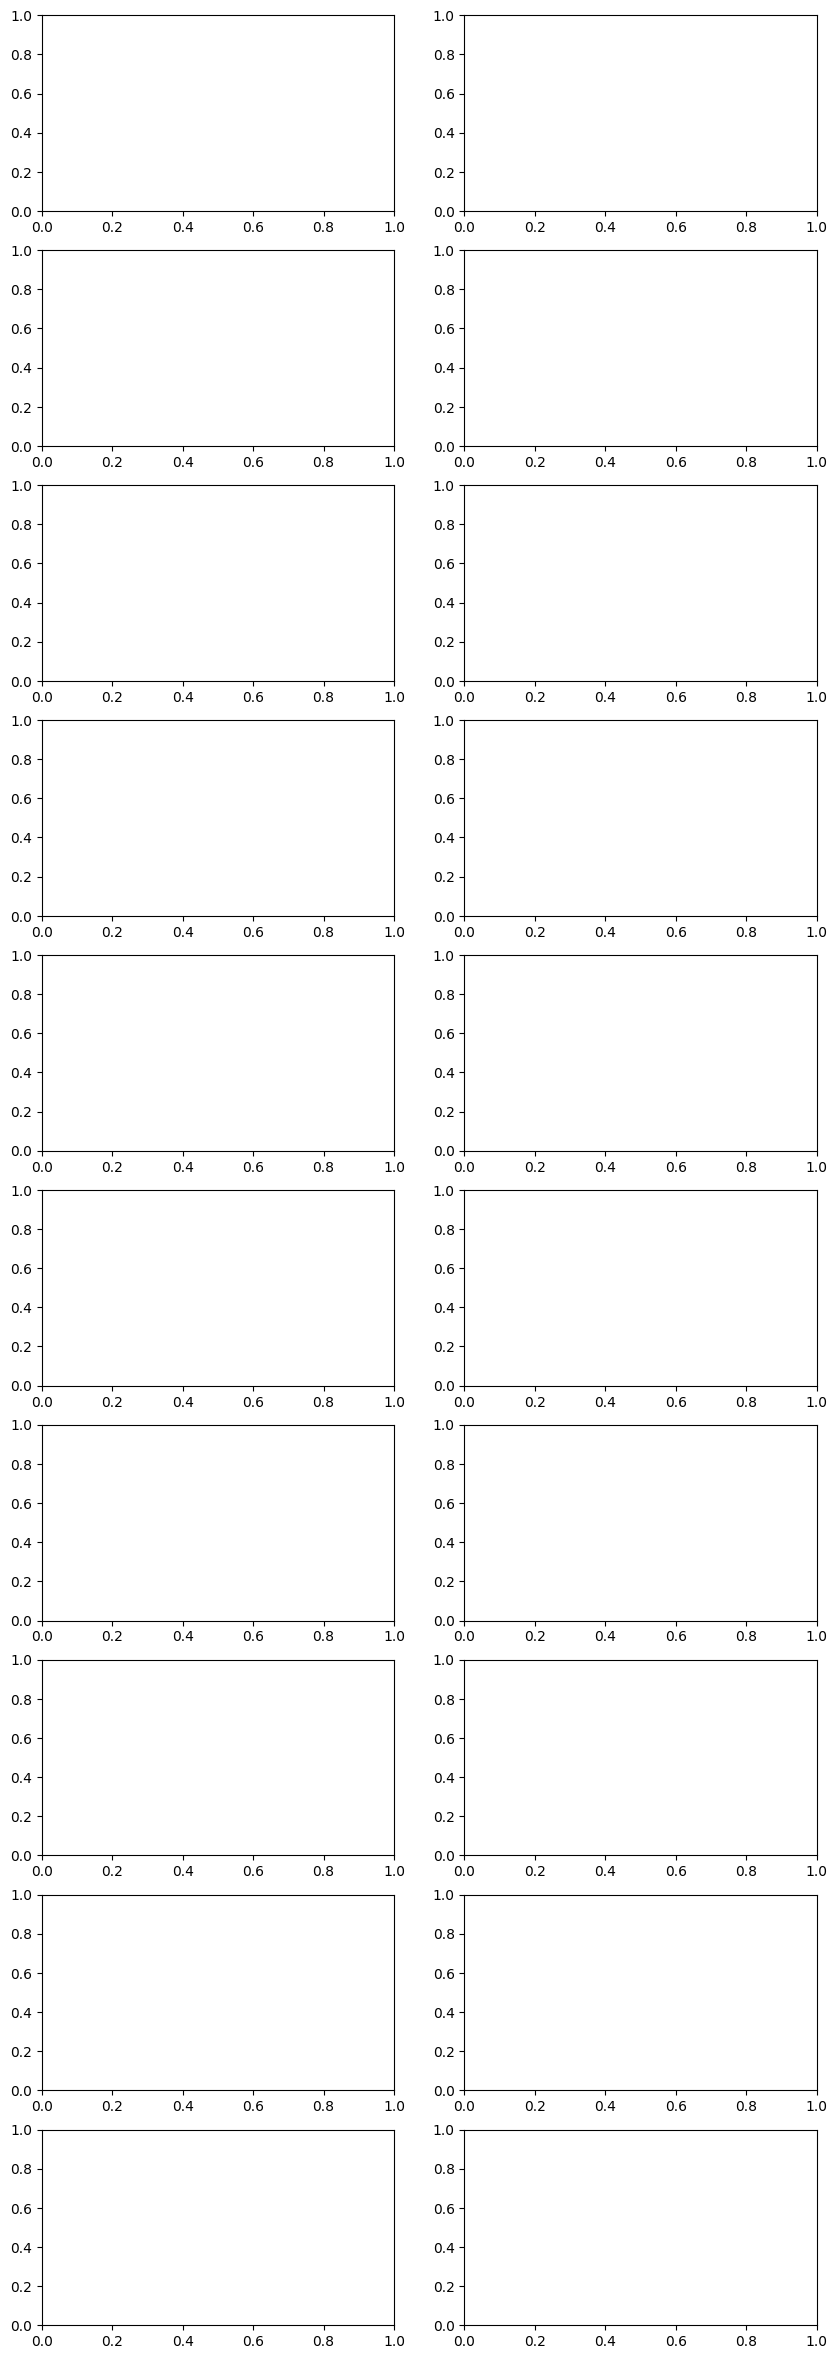

In [109]:
fig, axes = plt.subplots(len(dates_to_plot), 2, figsize=(10, 3 * len(dates_to_plot)))

if len(dates_to_plot) == 1:
    axes = np.expand_dims(axes, axis=0)

for i, d in enumerate(dates_to_plot):
    idx = np.where(test_dates == d)[0][0]

    true_map = np.squeeze(true[idx, -1])
    pred_map = np.squeeze(pred[idx, -1])

    if TASK_TYPE == "binary":
        pred_map = (pred_map >= best_thr).astype(np.uint8)
        vmin, vmax = 0, 1
    else:
        true_map = true_map * (std + 1e-6) + mean
        pred_map = pred_map * (std + 1e-6) + mean

        vmin = min(true_map.min(), pred_map.min())
        vmax = max(true_map.max(), pred_map.max())

    im1 = axes[i, 0].pcolormesh(lons, lats, true_map, shading="auto", vmin=vmin, vmax=vmax)
    axes[i, 0].set_title(f"True - {str(d)}")
    axes[i, 0].set_xlabel("Lon")
    axes[i, 0].set_ylabel("Lat")
    fig.colorbar(im1, ax=axes[i, 0])

    im2 = axes[i, 1].pcolormesh(lons, lats, pred_map, shading="auto", vmin=vmin, vmax=vmax)
    axes[i, 1].set_title(f"Predicted - {str(d)}")
    axes[i, 1].set_xlabel("Lon")
    axes[i, 1].set_ylabel("Lat")
    fig.colorbar(im2, ax=axes[i, 1])

plt.tight_layout()
plt.show()

In [106]:
print("pred shape:", pred.shape)
print("true shape:", true.shape)

idx = 0
print("pred[idx] shape:", pred[idx].shape)
print("true[idx] shape:", true[idx].shape)

print("pred[idx] ndim:", pred[idx].ndim)
print("true[idx] ndim:", true[idx].ndim)

pred shape: (36, 1, 49, 200)
true shape: (36, 1, 49, 200)
pred[idx] shape: (1, 49, 200)
true[idx] shape: (1, 49, 200)
pred[idx] ndim: 3
true[idx] ndim: 3


In [107]:
def extract_last_map(arr, idx):
    x = np.asarray(arr[idx])
    print("before reshape:", x.shape)
    x = x.reshape(-1, x.shape[-2], x.shape[-1])
    print("after reshape:", x.shape)
    return x[-1]

In [110]:
true_map = extract_last_map(true, idx)
pred_map = extract_last_map(pred, idx)

if TASK_TYPE == "binary":
    pred_map = (pred_map >= best_thr).astype(np.uint8)
    vmin, vmax = 0, 1
else:
    true_map = true_map * (std + 1e-6) + mean
    pred_map = pred_map * (std + 1e-6) + mean
    vmin = min(true_map.min(), pred_map.min())
    vmax = max(true_map.max(), pred_map.max())

before reshape: (1, 49, 200)
after reshape: (1, 49, 200)
before reshape: (1, 49, 200)
after reshape: (1, 49, 200)


## Centroid of largest connected component

In [77]:
import numpy as np

def to_nhw(arr):
    arr = np.asarray(arr)

    if arr.ndim < 3:
        raise ValueError(f"Expected at least 3 dims, got shape {arr.shape}")

    # keep first dim as sample/time dimension
    n = arr.shape[0]
    h, w = arr.shape[-2], arr.shape[-1]

    # flatten all middle dims and require exactly 1 map per sample
    middle = int(np.prod(arr.shape[1:-2]))
    if middle != 1:
        raise ValueError(
            f"Cannot safely convert shape {arr.shape} to (N,H,W): "
            f"there are {middle} maps per sample in middle dimensions."
        )

    return arr.reshape(n, h, w)


pred_maps = to_nhw(pred)
true_maps = to_nhw(true)

print("pred_maps shape:", pred_maps.shape)
print("true_maps shape:", true_maps.shape)

pred_maps shape: (36, 49, 200)
true_maps shape: (36, 49, 200)


In [92]:
def make_binary_maps(pred_window, true_window, task_type, best_thr=None, percentile=90):
    if task_type == "binary":
        if best_thr is None:
            raise ValueError("best_thr required for binary task")
        pred_bin = (pred_window >= best_thr).astype(np.uint8)
        true_bin = (true_window >= 0.5).astype(np.uint8)
    else:
        thr = np.nanpercentile(true_window, percentile)
        pred_bin = (pred_window >= thr).astype(np.uint8)
        true_bin = (true_window >= thr).astype(np.uint8)
    return pred_bin, true_bin

In [81]:
def largest_component_centroid(mask, lats, lons, min_pixels=10):
    """
    mask: (H, W) binary mask
    returns: centroid_lat, centroid_lon, area
    """
    mask = (mask > 0).astype(np.uint8)
    structure = np.ones((3, 3), dtype=np.uint8)  # 8-connectivity
    labeled, num_features = ndimage.label(mask, structure=structure)

    if num_features == 0:
        return np.nan, np.nan, 0

    best_area = 0
    best_lat = np.nan
    best_lon = np.nan

    for label_id in range(1, num_features + 1):
        rows, cols = np.where(labeled == label_id)
        area = len(rows)

        if area < min_pixels:
            continue

        if area > best_area:
            best_area = area
            best_lat = float(np.mean(lats[rows]))
            best_lon = float(np.mean(lons[cols]))

    if best_area == 0:
        return np.nan, np.nan, 0

    return best_lat, best_lon, best_area

In [ ]:
# convert to (N,H,W)
pred_maps = to_nhw(pred)
true_maps = to_nhw(true)

# select date window
start_date = np.datetime64("2003-07-27")
end_date   = np.datetime64("2003-08-18")
window_mask = (test_dates >= start_date) & (test_dates <= end_date)

dates_window = test_dates[window_mask]
pred_window = pred_maps[window_mask]
true_window = true_maps[window_mask]

In [96]:
# create binary masks
pred_bin_window, true_bin_window = make_binary_maps(
    pred_window, true_window,
    task_type=TASK_TYPE,
    best_thr=best_thr if TASK_TYPE == "binary" else None,
    percentile=85
)

print("pred_bin unique:", np.unique(pred_bin_window))
print("true_bin unique:", np.unique(true_bin_window))

for t in range(min(5, len(dates_window))):
    print(
        f"{dates_window[t]} | pred positives={pred_bin_window[t].sum()} | true positives={true_bin_window[t].sum()}"
    )

true_lat_traj, true_lon_traj, true_area = [], [], []
pred_lat_traj, pred_lon_traj, pred_area = [], [], []

for t in range(len(dates_window)):
    lat_t, lon_t, area_t = largest_component_centroid(true_bin_window[t], lats, lons, min_pixels=1)
    true_lat_traj.append(lat_t)
    true_lon_traj.append(lon_t)
    true_area.append(area_t)

    lat_p, lon_p, area_p = largest_component_centroid(pred_bin_window[t], lats, lons, min_pixels=1)
    pred_lat_traj.append(lat_p)
    pred_lon_traj.append(lon_p)
    pred_area.append(area_p)

true_lat_traj = np.array(true_lat_traj)
true_lon_traj = np.array(true_lon_traj)
true_area = np.array(true_area)

pred_lat_traj = np.array(pred_lat_traj)
pred_lon_traj = np.array(pred_lon_traj)
pred_area = np.array(pred_area)

pred_bin unique: [0]
true_bin unique: [0 1]
2003-07-27 | pred positives=0 | true positives=400
2003-07-28 | pred positives=0 | true positives=446
2003-07-29 | pred positives=0 | true positives=243
2003-07-30 | pred positives=0 | true positives=381
2003-07-31 | pred positives=0 | true positives=0


In [98]:
print("pred_bin unique:", np.unique(pred_bin_window))
for t in range(5):
    print(t, pred_bin_window[t].sum(), true_bin_window[t].sum())

pred_bin unique: [0]
0 0 400
1 0 446
2 0 243
3 0 381
4 0 0


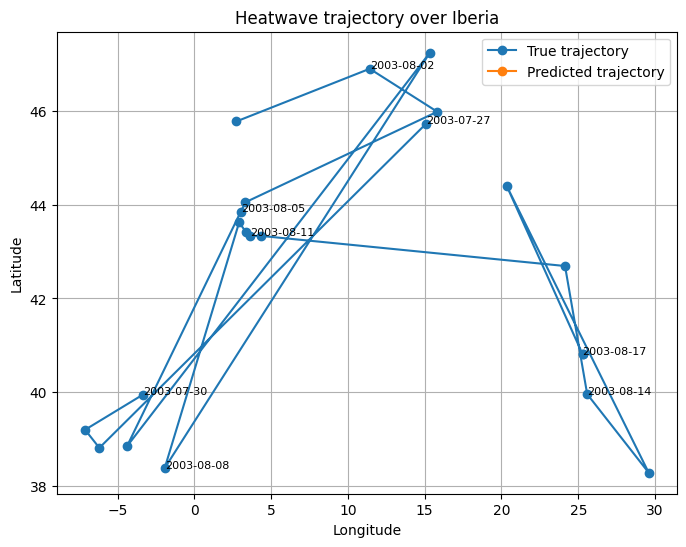

In [94]:
plt.figure(figsize=(8, 6))
plt.plot(true_lon_traj, true_lat_traj, marker="o", label="True trajectory")
plt.plot(pred_lon_traj, pred_lat_traj, marker="o", label="Predicted trajectory")

for i, d in enumerate(dates_window):
    if i % 3 == 0:
        plt.text(true_lon_traj[i], true_lat_traj[i], str(d)[:10], fontsize=8)
        plt.text(pred_lon_traj[i], pred_lat_traj[i], str(d)[:10], fontsize=8)

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Heatwave trajectory over Iberia")
plt.legend()
plt.grid(True)
plt.show()

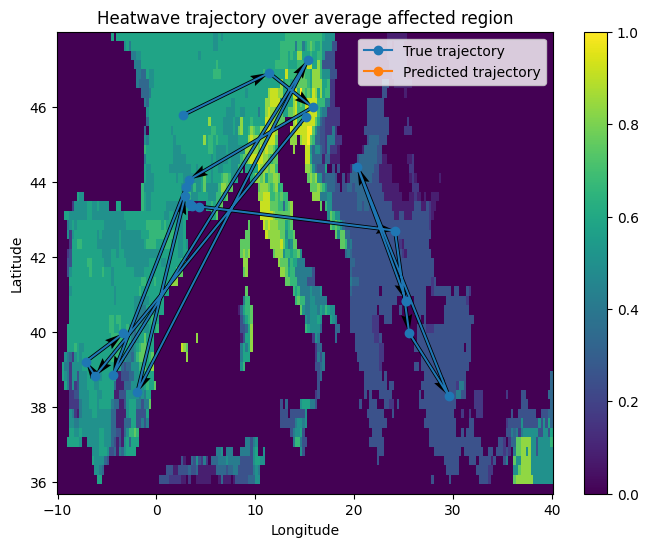

In [95]:
mean_true_mask = true_bin_window.mean(axis=0)

plt.figure(figsize=(8, 6))
plt.pcolormesh(lons, lats, mean_true_mask, shading="auto")

# plot trajectories
plt.plot(true_lon_traj, true_lat_traj, marker="o", label="True trajectory")
plt.plot(pred_lon_traj, pred_lat_traj, marker="o", label="Predicted trajectory")

# arrows for TRUE trajectory
plt.quiver(
    true_lon_traj[:-1], true_lat_traj[:-1],
    np.diff(true_lon_traj), np.diff(true_lat_traj),
    angles='xy', scale_units='xy', scale=1
)

# arrows for PRED trajectory
plt.quiver(
    pred_lon_traj[:-1], pred_lat_traj[:-1],
    np.diff(pred_lon_traj), np.diff(pred_lat_traj),
    angles='xy', scale_units='xy', scale=1
)

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Heatwave trajectory over average affected region")
# plt.axis("equal") # 1 degree lat ~ 1 degree lon in this region, so equal aspect ratio 

plt.legend()
plt.colorbar()
plt.show()

#### how often each pixel was labeled as is_heatwave during the time window, for instance pixels with value 1.0 were affected by the heatwave for the whole time window

### Did the predicted trajectory move through the actual heatwave region?

In [85]:
start_date = datetime(2003, 7, 27)
T = true_bin_window.shape[0]
dates = [start_date + timedelta(days=i) for i in range(T)]

# align predictions to true dates
pred_lon_aligned = np.full(T, np.nan)
pred_lat_aligned = np.full(T, np.nan)
pred_lon_aligned[1:] = pred_lon_traj[:-1]
pred_lat_aligned[1:] = pred_lat_traj[:-1]

frame_dir = "gif_frames"
os.makedirs(frame_dir, exist_ok=True)
frame_paths = []

for t in range(T):
    fig, ax = plt.subplots(figsize=(8, 6))

    pcm = ax.pcolormesh(lons, lats, true_bin_window[t], shading="auto")

    # true trajectory so far
    ax.plot(
        true_lon_traj[:t+1],
        true_lat_traj[:t+1],
        marker="o",
        label="True trajectory"
    )

    # predicted trajectory so far (aligned)
    ax.plot(
        pred_lon_aligned[:t+1],
        pred_lat_aligned[:t+1],
        marker="o",
        label="Predicted trajectory"
    )

    # true arrow
    if t > 0:
        if not np.any(np.isnan([
            true_lon_traj[t-1], true_lat_traj[t-1],
            true_lon_traj[t], true_lat_traj[t]
        ])):
            ax.arrow(
                true_lon_traj[t-1], true_lat_traj[t-1],
                true_lon_traj[t] - true_lon_traj[t-1],
                true_lat_traj[t] - true_lat_traj[t-1],
                length_includes_head=True,
                head_width=0.3,
                head_length=0.3
            )

    # predicted arrow
    if t > 1:
        if not np.any(np.isnan([
            pred_lon_aligned[t-1], pred_lat_aligned[t-1],
            pred_lon_aligned[t], pred_lat_aligned[t]
        ])):
            ax.arrow(
                pred_lon_aligned[t-1], pred_lat_aligned[t-1],
                pred_lon_aligned[t] - pred_lon_aligned[t-1],
                pred_lat_aligned[t] - pred_lat_aligned[t-1],
                length_includes_head=True,
                head_width=0.3,
                head_length=0.3
            )

    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.set_title(f"Heatwave propagation - {dates[t].strftime('%d.%m.%Y')}")
    ax.legend(loc="upper right")
    fig.colorbar(pcm, ax=ax, label="True heatwave mask")
    ax.set_aspect("equal")

    frame_path = os.path.join(frame_dir, f"frame_{t:02d}.png")
    plt.savefig(frame_path, dpi=150, bbox_inches="tight")
    plt.close(fig)
    frame_paths.append(frame_path)

gif_path = "heatwave_daily_true_vs_pred.gif"
with imageio.get_writer(gif_path, mode="I", fps=1) as writer:
    for frame_path in frame_paths:
        writer.append_data(imageio.imread(frame_path))

print(f"Saved GIF to: {gif_path}")

Saved GIF to: heatwave_daily_true_vs_pred.gif


In [ ]:
centroid_error = np.sqrt((true_lat_traj - pred_lat_traj)**2 + (true_lon_traj - pred_lon_traj)**2)

print("Mean centroid error (degrees):", np.nanmean(centroid_error))
print("Median centroid error (degrees):", np.nanmedian(centroid_error))

Mean centroid error (degrees): 2.668162662849719
Median centroid error (degrees): 2.680623563902807


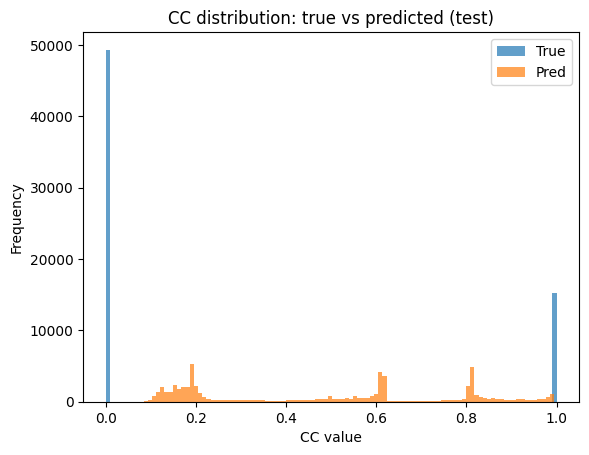

In [ ]:
plt.figure()
plt.hist(true.ravel(), bins=100, alpha=0.7, label="True")
plt.hist(pred.ravel(), bins=100, alpha=0.7, label="Pred")
plt.title("CC distribution: true vs predicted (test)")
plt.xlabel("CC value")
plt.ylabel("Frequency")
plt.legend()
plt.show()


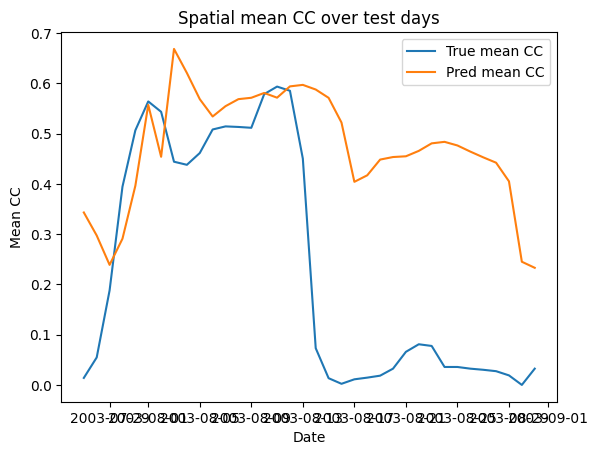

In [ ]:
true_mean = true.mean(axis=(2,3)).squeeze()  # (N,)
pred_mean = pred.mean(axis=(2,3)).squeeze()

plt.figure()
plt.plot(test_dates, true_mean, label="True mean CC")
plt.plot(test_dates, pred_mean, label="Pred mean CC")
plt.title("Spatial mean CC over test days")
plt.xlabel("Date")
plt.ylabel("Mean CC")
plt.legend()
plt.show()

## Can the model learn network structure evolution?

Degree Centrality (DC)

How synchronized a region is with others.

➡ high = many regions experiencing heat together
➡ hubs of heatwave activity

Clustering Coefficient (CC)

Local clustering of heatwaves.

➡ high = localized heatwave cluster
➡ stationary behaviour

Betweenness Centrality (BC)

Propagation corridor importance.

➡ high = heatwave movement pathway
➡ dynamic propagation routes

Use CN metrics to:

✔ identify propagation corridors
✔ detect dynamic heatwaves
✔ validate DL trajectories

Use is_heatwave to:

✔ define events
✔ train models
✔ detect movement

Use E-OBS Tmax to:

✔ build sequences
✔ provide physical context